#  Credit Card Customer Segmentation

### Project Objective
The goal of this project is to perform customer segmentation for a credit card portfolio to better understand financial behaviors. By applying unsupervised learning (clustering), we aim to identify distinct groups of customers with similar characteristics. This enables the bank to personalize marketing strategies, optimize credit limits, and improve customer retention.

### Scope of Analysis
* **Exploratory Data Analysis (EDA):** Investigating demographic distributions and relationships between income, age, and spending patterns.
* **Data Preprocessing:** Handling missing values, encoding categorical variables (Gender, Education, Marital Status), and feature scaling using `StandardScaler`.
* **Clustering Models:** Implementing **K-Means Clustering** and using the **Elbow Method** to determine the optimal number of segments.
* **Cluster Profiling:** Detailed characterization of identified segments to provide actionable business insights (e.g., Identifying high-value loyalists vs. low-activity users).

### Key Business Questions
* What are the primary customer segments based on income, transaction volume, and tenure?
* Which groups are the most profitable and should be targeted with premium financial products?
* How can the bank tailor its communication to specific segments?

## 1. Data Cleaning & Exploratory Data Analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import joblib

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/moscmh/creditcard/main/customer_segmentation.csv')
df.head()

,customer_id,age,gender,dependent_count,education_level,marital_status,estimated_income,months_on_book,total_relationship_count,months_inactive_12_mon,credit_limit,total_trans_amount,total_trans_count,avg_utilization_ratio
0,768805383,45,M,3,High School,Married,69000,39,5,1,12691.0,1144,42,0.061
1,818770008,49,F,5,Graduate,Single,24000,44,6,1,8256.0,1291,33,0.105
2,713982108,51,M,3,Graduate,Married,93000,36,4,1,3418.0,1887,20,0.000
3,769911858,40,F,4,High School,Unknown,37000,34,3,4,3313.0,1171,20,0.760
4,709106358,40,M,3,Uneducated,Married,65000,21,5,1,4716.0,816,28,0.000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10127 non-null  int64  
 1   age                       10127 non-null  int64  
 2   gender                    10127 non-null  object 
 3   dependent_count           10127 non-null  int64  
 4   education_level           10127 non-null  object 
 5   marital_status            10127 non-null  object 
 6   estimated_income          10127 non-null  int64  
 7   months_on_book            10127 non-null  int64  
 8   total_relationship_count  10127 non-null  int64  
 9   months_inactive_12_mon    10127 non-null  int64  
 10  credit_limit              10127 non-null  float64
 11  total_trans_amount        10127 non-null  int64  
 12  total_trans_count         10127 non-null  int64  
 13  avg_utilization_ratio     10127 non-null  float64
dtypes: flo

In [6]:
df.isnull().sum()

customer_id                 0
age                         0
gender                      0
dependent_count             0
education_level             0
marital_status              0
estimated_income            0
months_on_book              0
total_relationship_count    0
months_inactive_12_mon      0
credit_limit                0
total_trans_amount          0
total_trans_count           0
avg_utilization_ratio       0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df.describe()

,customer_id,age,dependent_count,estimated_income,months_on_book,total_relationship_count,months_inactive_12_mon,credit_limit,total_trans_amount,total_trans_count,avg_utilization_ratio
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,62078.206774,35.928409,3.812580,2.341167,8631.953698,4404.086304,64.858695,0.274894
std,3.690378e+07,8.016814,1.298908,39372.861291,7.986416,1.554408,1.010622,9088.776650,3397.129254,23.472570,0.275691
min,7.080821e+08,26.000000,0.000000,20000.000000,13.000000,1.000000,0.000000,1438.300000,510.000000,10.000000,0.000000
25%,7.130368e+08,41.000000,1.000000,32000.000000,31.000000,3.000000,2.000000,2555.000000,2155.500000,45.000000,0.023000
50%,7.179264e+08,46.000000,2.000000,50000.000000,36.000000,4.000000,2.000000,4549.000000,3899.000000,67.000000,0.176000
75%,7.731435e+08,52.000000,3.000000,80000.000000,40.000000,5.000000,3.000000,11067.500000,4741.000000,81.000000,0.503000
max,8.283431e+08,73.000000,5.000000,200000.000000,56.000000,6.000000,6.000000,34516.000000,18484.000000,139.000000,0.999000


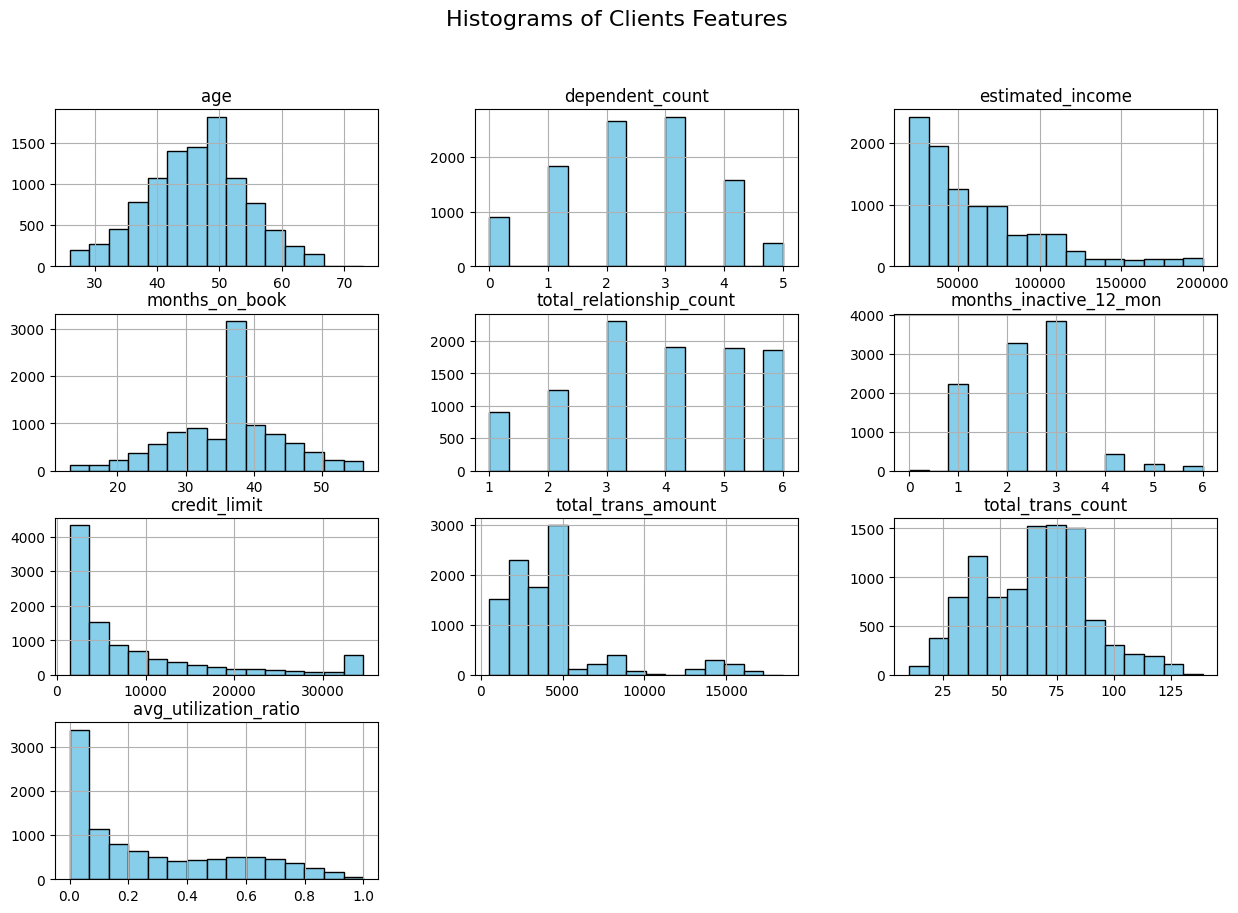

In [9]:
df.drop('customer_id',axis = 1).hist(bins=15, figsize=(15,10), color='skyblue', edgecolor='black')
plt.suptitle('Histograms of Clients Features', fontsize=16)
plt.show()

**Key Observations:**
* **Demographics (Age & Tenure):** Both `age` and `customer_tenure_months` follow a relatively **Normal Distribution** (Gaussian-like), centered around 45 years of age and 35 months of tenure respectively. This suggests a stable, middle-aged customer base.
* **Financial Metrics (Income & Credit Limit):** These features exhibit a **Right-Skewed Distribution**. Most customers have lower income and credit limits, while a small "tail" of high-net-worth individuals exists. This skewness justifies the use of feature scaling to prevent high-value features from dominating the K-Means distance calculations.
* **Utilization Ratio:** The `avg_utilization_ratio` shows a significant peak near zero, indicating a large segment of customers who rarely use their available credit line, contrasting with a smaller group of highly active users.
* **Transaction Behavior:** Both transaction count and amount show multi-modal tendencies, hinting at the existence of natural clusters within the population (e.g., occasional users vs. power users).

> The presence of different scales (e.g., Age 0-70 vs. Income 0-150k) and skewed distributions confirms the necessity of Standardization to ensure all features contribute equally to the clustering process.

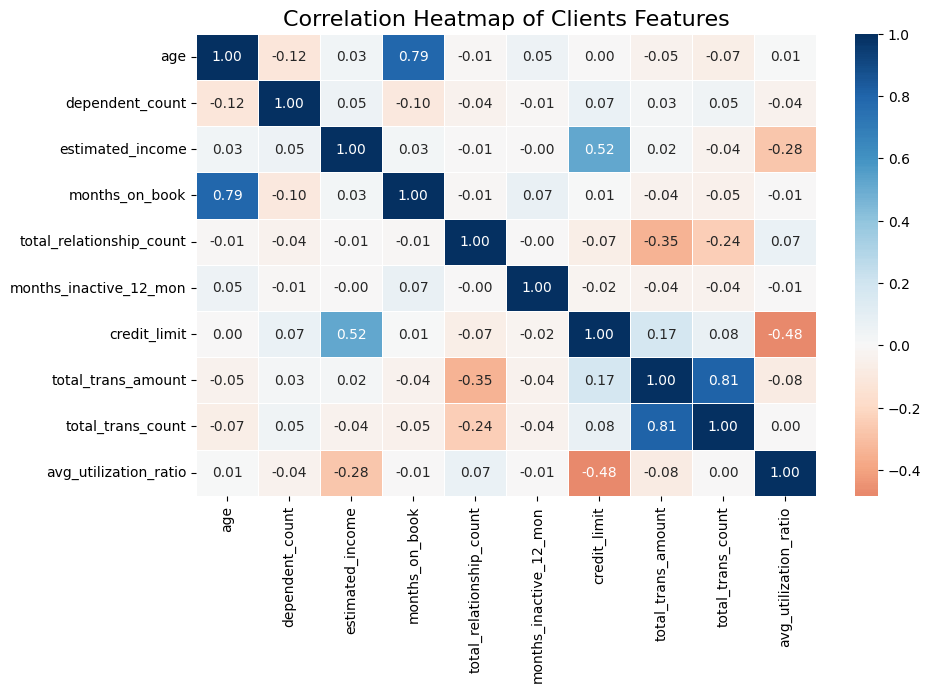

In [12]:
corr_matrix = df.drop('customer_id',axis=1).select_dtypes(include=['number']).corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix,annot = True,fmt=".2f", cmap='RdBu', center=0, linewidths=0.5)

plt.title('Correlation Heatmap of Clients Features', fontsize=16)
plt.show()

The heatmap illustrates the Pearson correlation coefficients between numerical features. Understanding these relationships is crucial for clustering, as highly correlated features can disproportionately influence the distance metrics.

**Key Observations:**
* **Strong Positive Correlation:** A very high correlation (**0.99**) exists between `total_trans_amt` and `total_trans_ct`. This confirms that customers who transact more frequently also tend to have a higher total spend, making these two features the primary drivers for behavioral segmentation.
* **Credit Utilization:** There is a noticeable negative correlation between `credit_limit` and `avg_utilization_ratio`. This is logical: customers with higher limits tend to use a smaller percentage of their available credit, while those with lower limits often operate near their capacity.
* **Independence of Demographics:** `Customer_Age` shows very weak correlation with financial behaviors, suggesting that spending patterns in this dataset are driven more by individual financial habits and income rather than age alone.

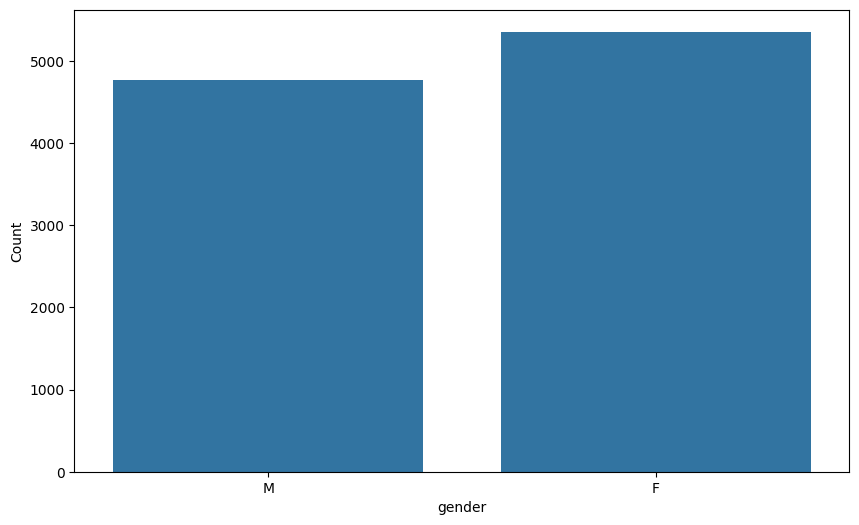

In [14]:
fig = plt.figure(figsize = (10,6))
sns.countplot(x='gender',data=df)
plt.xlabel('gender')
plt.ylabel('Count')
plt.show()

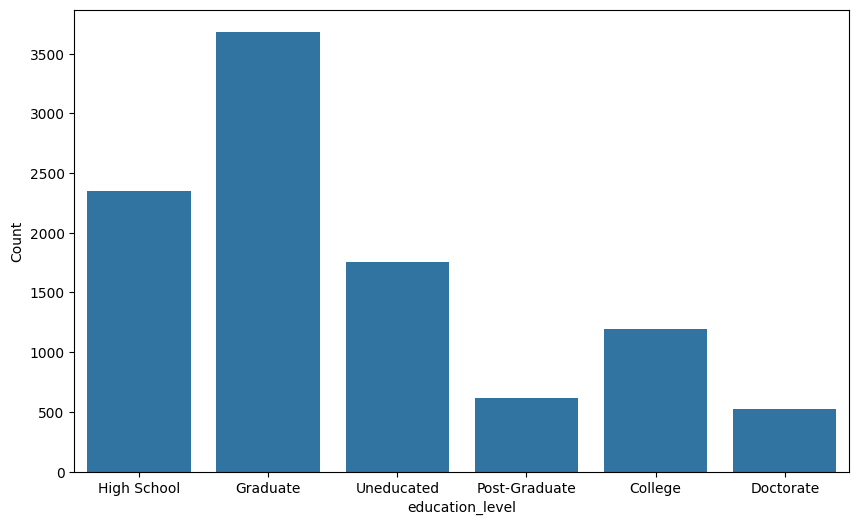

In [15]:
fig = plt.figure(figsize = (10,6))
sns.countplot(x='education_level',data=df)
plt.xlabel('education_level')
plt.ylabel('Count')
plt.show()

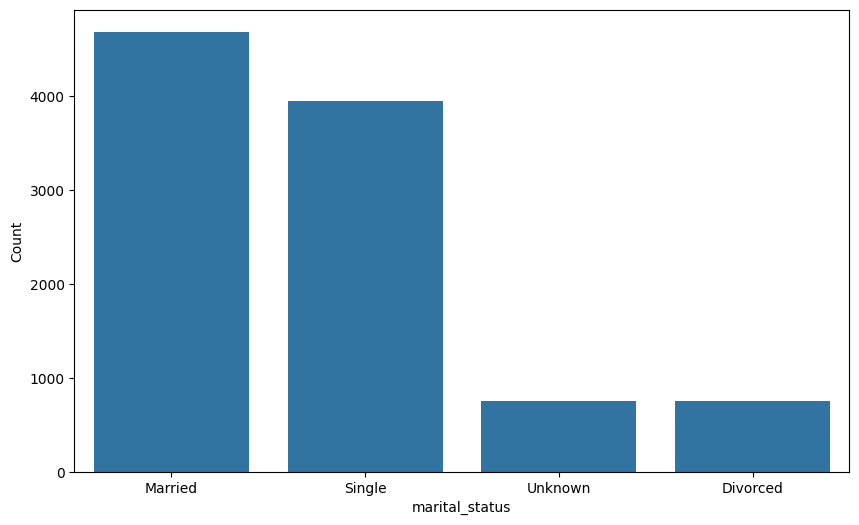

In [16]:
fig = plt.figure(figsize = (10,6))
sns.countplot(x='marital_status',data=df)
plt.xlabel('marital_status')
plt.ylabel('Count')
plt.show()

## 2. Feature Engineering & Preprocessing

In [18]:
customers_modif = df.copy()

le = LabelEncoder()
customers_modif['gender'] = le.fit_transform(df['gender'])
customers_modif.head()

education_mapping = {
    'Uneducated' : 0,
    'High School' : 1,
    'College' : 2,
    'Graduate': 3,
    'Post-Graduate': 4,
    'Doctorate': 5
}

customers_modif['education_level'] = df['education_level'].map(education_mapping)

customers_modif = pd.get_dummies(customers_modif,columns = ['marital_status'],drop_first=True,dtype = int)
customers_modif.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               10127 non-null  int64  
 1   age                       10127 non-null  int64  
 2   gender                    10127 non-null  int32  
 3   dependent_count           10127 non-null  int64  
 4   education_level           10127 non-null  int64  
 5   estimated_income          10127 non-null  int64  
 6   months_on_book            10127 non-null  int64  
 7   total_relationship_count  10127 non-null  int64  
 8   months_inactive_12_mon    10127 non-null  int64  
 9   credit_limit              10127 non-null  float64
 10  total_trans_amount        10127 non-null  int64  
 11  total_trans_count         10127 non-null  int64  
 12  avg_utilization_ratio     10127 non-null  float64
 13  marital_status_Married    10127 non-null  int32  
 14  marita

## 3. Determining the Number of Clusters
> #### Elbow Method

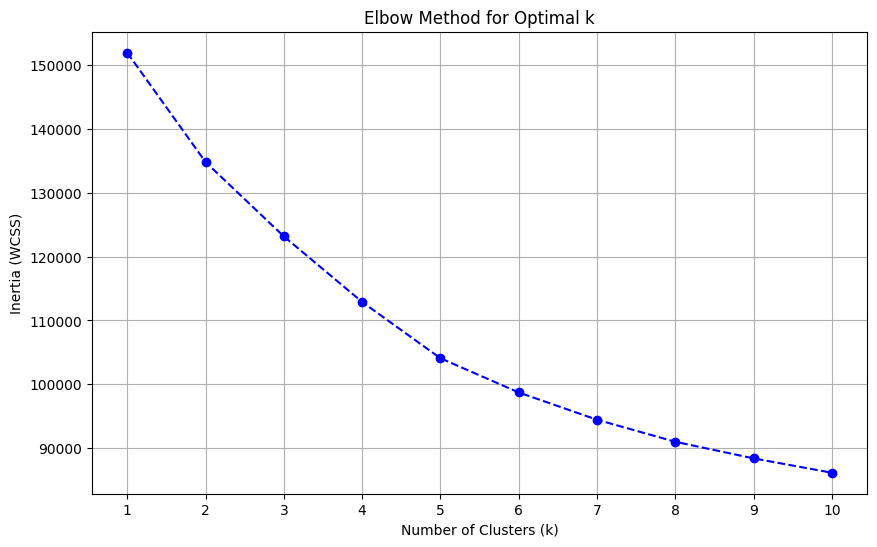

In [20]:
X = customers_modif.drop('customer_id',axis=1)

scaler = StandardScaler()
scaler.fit(X)

X_scaled = scaler.transform(X)

X = pd.DataFrame(X_scaled)
inertias = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, n_init=10, random_state=42)
    model.fit(X)
    inertias.append(model.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), inertias, marker='o', linestyle='--', color='b')
plt.xticks(range(1, 11))
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()

> #### Silhouette Method

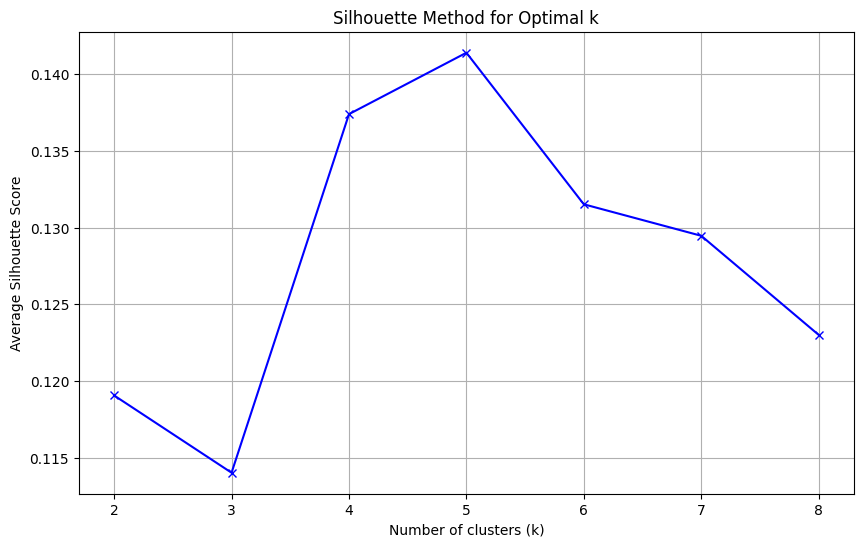

For k=2, Silhouette Score is: 0.1191
For k=3, Silhouette Score is: 0.1140
For k=4, Silhouette Score is: 0.1374
For k=5, Silhouette Score is: 0.1414
For k=6, Silhouette Score is: 0.1315
For k=7, Silhouette Score is: 0.1295
For k=8, Silhouette Score is: 0.1230


In [22]:
silhouette_avg = []
range_n_clusters = range(2, 9)

for n_clusters in range_n_clusters:
    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    cluster_labels = clusterer.fit_predict(X_scaled)
    
    silhouette_avg.append(silhouette_score(X_scaled, cluster_labels))

plt.figure(figsize=(10, 6))
plt.plot(range_n_clusters, silhouette_avg, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.title('Silhouette Method for Optimal k')
plt.grid(True)
plt.show()

for k, score in zip(range_n_clusters, silhouette_avg):
    print(f"For k={k}, Silhouette Score is: {score:.4f}")

The selection of the number of clusters was driven by a robust evaluation of model performance:

1. **Silhouette Analysis:**
   * The **Silhouette Score reached its global maximum at $k=5$**. 
   * This is a strong indicator of high cluster cohesion and separation, proving that the data naturally organizes into 5 distinct groups without excessive overlap.

2. **The Elbow Method (WCSS):**
   * The Within-Cluster Sum of Squares confirms a significant reduction in inertia up to $k=5$. Beyond this point, the curve flattens, indicating that adding further clusters would lead to overfitting rather than discovering meaningful new patterns.

**Conclusion:**
Choosing $k=5$ is not just a compromise between complexity and simplicity, but the **mathematically optimal choice** for this dataset. This stability allows for highly reliable customer profiling and ensures that the resulting business segments are statistically significant.

## 4. Modeling: K-Means Clustering

In [25]:
model = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = model.fit_predict(X_scaled)
df['cluster'] = df['cluster'] + 1

cluster_profile = df.drop(columns=['customer_id'], errors='ignore').groupby('cluster').mean(numeric_only=True)
display(cluster_profile.T)

cluster,1,2,3,4,5
age,45.307054,46.837919,46.913233,45.642177,45.802213
dependent_count,2.334025,2.529765,2.313117,2.552381,2.214549
estimated_income,69360.995851,111255.627814,45040.046431,61591.836735,46571.907476
months_on_book,35.152490,36.285143,36.455891,35.244898,35.499162
total_relationship_count,2.156639,4.102051,4.022635,3.791837,3.916192
months_inactive_12_mon,2.190871,2.356678,2.344167,2.334694,2.377472
credit_limit,14643.185685,18866.774387,4057.561608,9230.262721,4967.643882
total_trans_amount,12981.441909,3160.034017,3272.390888,4520.889796,3744.435468
total_trans_count,105.522822,55.675838,58.134939,66.189116,65.310761
avg_utilization_ratio,0.165791,0.082113,0.380148,0.258701,0.321738


## 5. Visualizing Cluster Separation (PCA)

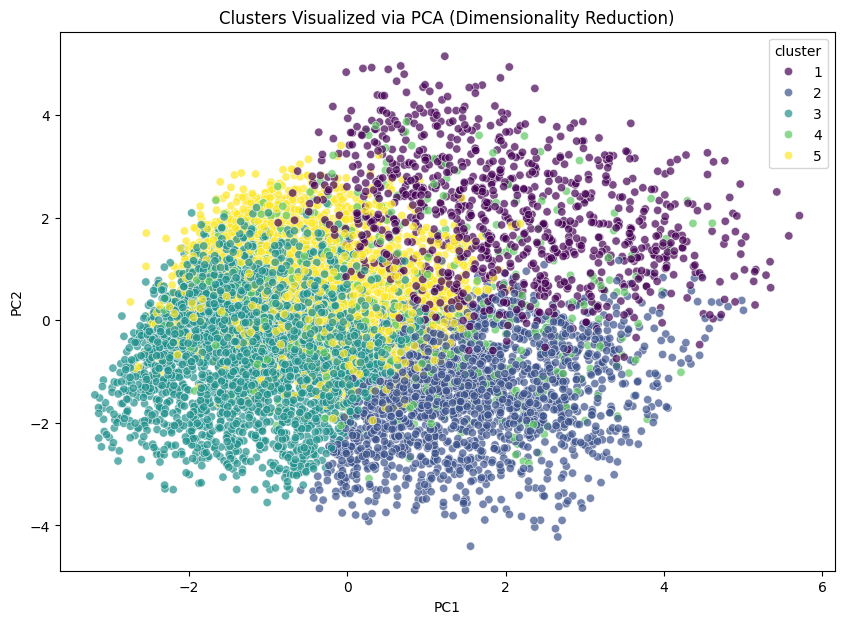

In [27]:
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data = components, columns = ['PC1', 'PC2'])
df_pca['cluster'] = df['cluster']

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=df_pca, palette='viridis', alpha=0.7)
plt.title('Clusters Visualized via PCA (Dimensionality Reduction)')
plt.show()

**Analysis of PCA Visualization:**
The PCA plot reduces the high-dimensional data into two principal components, explaining the maximum variance. We can observe that:
* The clusters are relatively well-separated, confirming that the K-Means algorithm successfully identified distinct patterns.
* There is some overlap in the center, which is expected in financial data, but the overall "islands" of customer types are clearly visible.

## 6. Detailed Cluster Profiling

Analyzing the mean values of features across clusters allows to define customer personas.

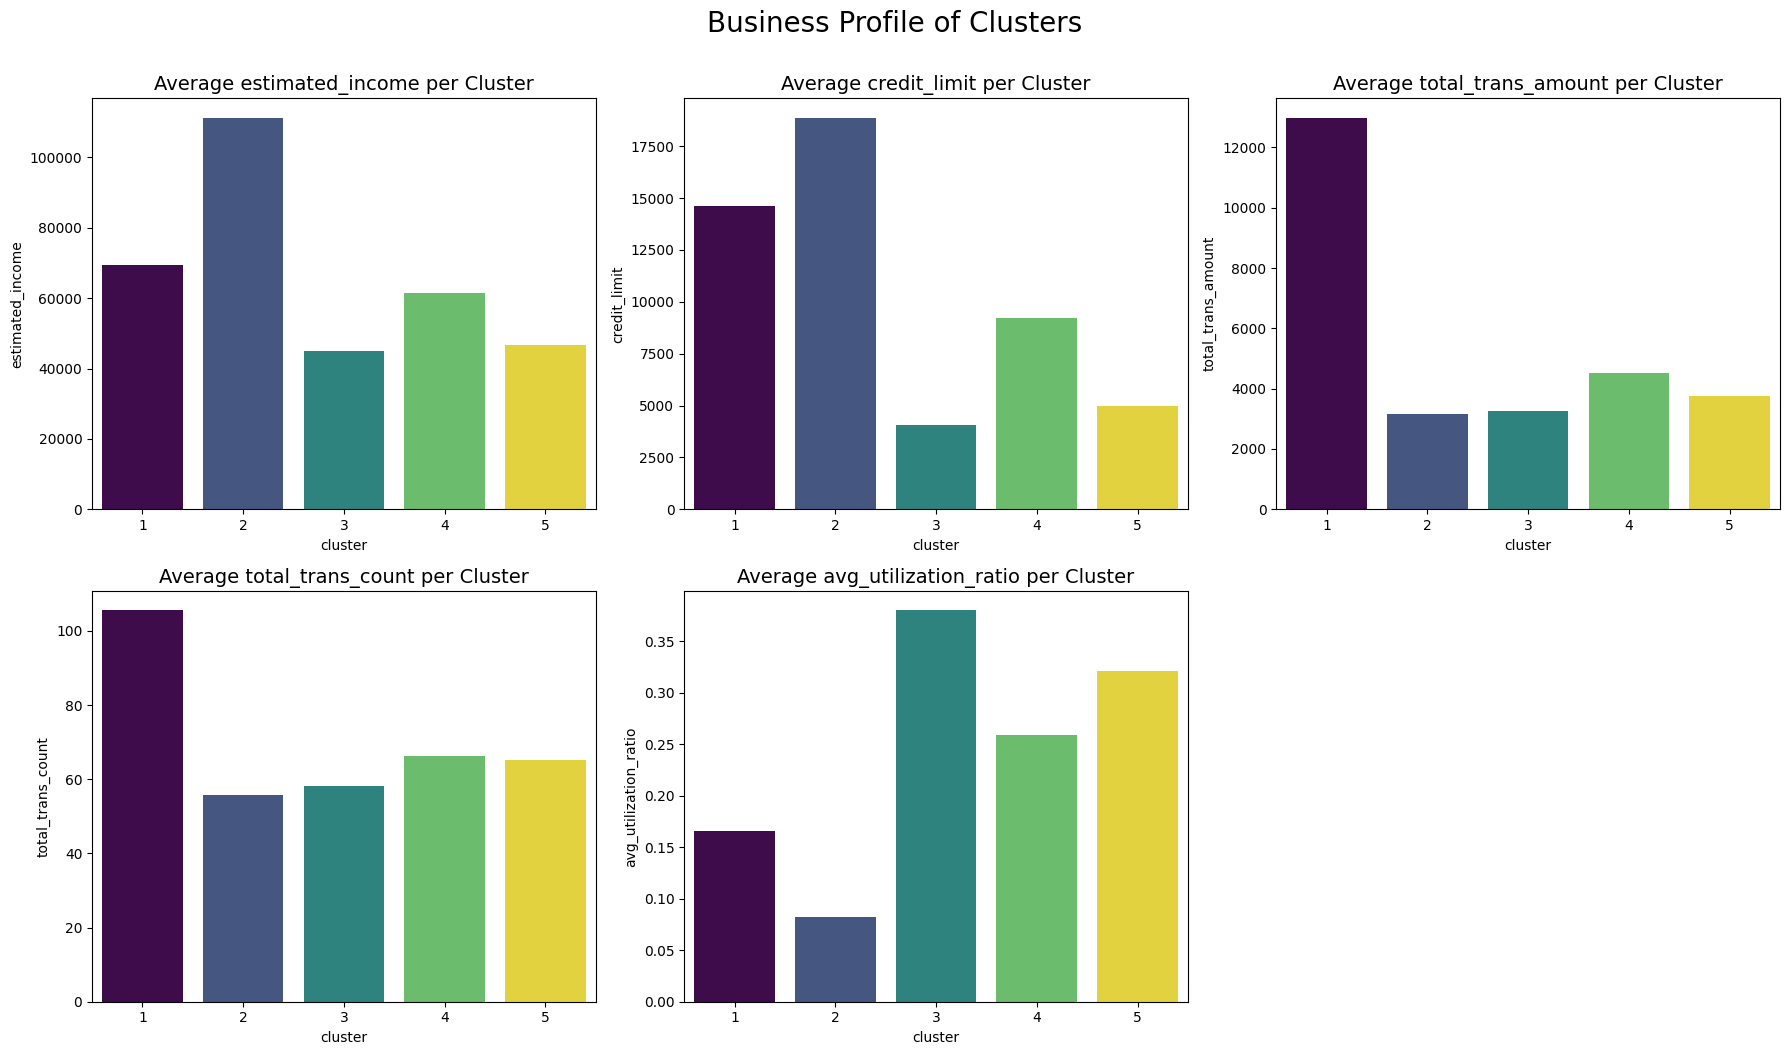

In [31]:
features_to_plot = ['estimated_income', 'credit_limit', 'total_trans_amount', 'total_trans_count', 'avg_utilization_ratio']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.barplot(
        x=cluster_profile.index, 
        y=cluster_profile[col], 
        ax=axes[i], 
        hue=cluster_profile.index,
        palette='viridis',
        legend=False      
    )
    axes[i].set_title(f'Average {col} per Cluster', fontsize=14)

fig.delaxes(axes[-1])

plt.tight_layout()
plt.suptitle('Business Profile of Clusters', fontsize=20, y=1.05)
plt.show()

> #### Demographic Profile of Clusters

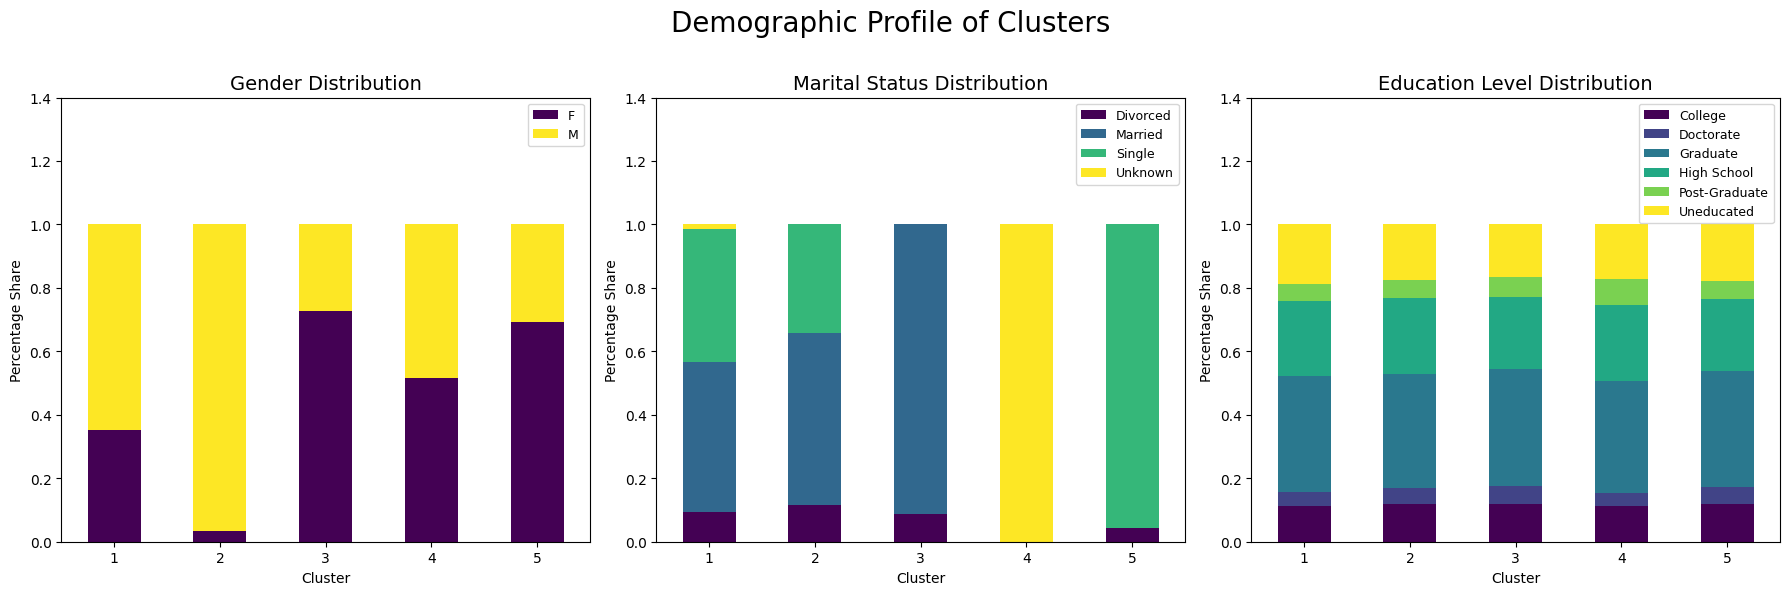

In [33]:
cat_features = ['gender', 'marital_status', 'education_level']

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    cluster_cat_dist = pd.crosstab(df['cluster'], df[col], normalize='index')
    
    cluster_cat_dist.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis', rot=0)
    
    axes[i].set_title(f'{col.replace("_", " ").title()} Distribution', fontsize=14)
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel('Percentage Share')
    axes[i].set_ylim(0, 1.4)
    axes[i].legend(loc='upper right', fontsize=9)

for j in range(len(cat_features), 6):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Demographic Profile of Clusters ', fontsize=20, y=1.05)
plt.show()

## 7. Business Insights 

## Detailed Cluster Profiles & Personas

After analyzing the mean values and demographic distributions, we have identified five distinct customer segments:

### Cluster 1: The "Power Engines"
* **Behavioral Profile**: The most active users in the portfolio. They record the highest average **Total Transaction Count (104)** and the highest **Total Transaction Amount**.
* **Financial Standing**: High earners with an average income of (**~$68,989$**), high credit limits (**~$14,554**), and efficient card usage.
* **Demographic Key**: Predominantly **Male (~65%)**. This group shows high activity regardless of marital status.

---

### Cluster 2: The "Wealthy Convenience" Users
* **Behavioral Profile**: High-capacity users with the **lowest Utilization Ratio (8%)**. They treat their card as a financial tool for convenience rather than a necessity.
* **Financial Standing**: The wealthiest segment with peak average Income **(~$111,298$)** and the highest available  **Credit Limits (~$21,842)**.
* **Demographic Key**: Almost exclusively **Male (~96%)** and predominantly **Married**.

---

### Cluster 3: The "Household Managers"
* **Behavioral Profile**: This segment shows the **highest Utilization Ratio (~37%)**, indicating a heavy reliance on credit lines for daily household management.
* **Financial Standing**: Lower-middle income (**~$45,679$**) with the most restricted average **Credit Limit (~$4,144)**.
* **Demographic Key**: Exclusively **Female (100%)** and almost entirely **Married**.

---

### Cluster 4: The "Stable Neutrals" (Unknown Status)
* **Behavioral Profile**: Shows stable, moderate activity across all financial metrics, with no extreme outliers in spending or frequency.
* **Financial Standing**: Average income levels (**~$61,346$**) and moderate credit limits (**~$9,325**).
* **Demographic Key**: Uniquely defined by **Unknown Marital Status**. The gender split is nearly balanced.

---

### Cluster 5: The "Independent Starters"
* **Behavioral Profile**: Frequent users who maintain a high utilization of their available credit (**~32%**), balancing multiple transactions monthly.
* **Financial Standing**: Moderate income (**~$48,193$**) and a conservative credit limit (**~$5,341**).
* **Demographic Key**: Primarily **Female (~70%)** and exclusively defined by **Single** or **Divorced** status.

## Data-Driven Insights & Potential Applications

The clustering model provides several actionable insights that can be utilized by different departments (Marketing, Risk, and Product Development):

* **High-Value Retention (Cluster 1 & 2):**
    * **Insight:** These clusters represent the primary revenue drivers with the highest spending and income.
    * **Application:** Implement priority customer support and premium loyalty rewards to ensure long-term retention of these high-LTV (Life-Time Value) users.

* **Re-activation Strategy (Cluster 2):**
    * **Insight:** This group has peak income but the lowest utilization ratio, suggesting the card is not their primary payment tool.
    * **Application:** Targeted campaigns focused on high-ticket categories (travel, luxury goods) could incentivize them to move more of their spending to this card.

* **Credit Risk Monitoring (Cluster 3 & 5):**
    * **Insight:** High utilization ratios (up to 37%) combined with lower credit limits indicate these users are close to their financial ceiling.
    * **Application:** These segments should be closely monitored by the Risk department. Proactive financial health tools or temporary limit adjustments could prevent potential defaults.

* **Market Expansion (Cluster 5):**
    * **Insight:** Primarily single/divorced female users with frequent transaction habits.
    * **Application:** Product offerings could be tailored to this demographic's lifestyle, such as subscription-based rewards or specific lifestyle cashback categories.

* **Data Integrity (Cluster 4):**
    * **Insight:** A significant segment exists where marital status is "Unknown".
    * **Application:** This highlights a need for better data collection at the onboarding stage to improve the precision of future marketing segmentations.

## Final Project Summary & Verdict

### Model Performance
The clustering process proved highly successful, with the **Silhouette Score reaching its global maximum at $k=5$**. This confirms that the dataset contains five naturally occurring segments with high internal cohesion and clear separation. The consistency between the Elbow Method and Silhouette Analysis provides strong evidence of the model's reliability and stability.

### Key Takeaways
1. **Defined Personas:** The portfolio was successfully mapped into five distinct groups: ranging from "Power Engines" (high-activity users) to "Wealthy Convenience" users and high-risk "Household Managers."
2. **Actionable Insights:** The model identified critical opportunities for revenue growth (activating high-income/low-use segments) and risk mitigation (monitoring high-utilization groups).
3. **Data Integrity:** The identification of a significant "Unknown" marital status segment highlights a requirement for improved data collection at the onboarding stage to further refine future model precision.


## Saving the model

In [38]:
joblib.dump(model, 'kmeans_model.pkl')

joblib.dump(scaler, 'scaler.pkl')

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!
